In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("car data.csv")

print(df.head())

print("\nShape:")
print(df.shape)

print("\nInfo:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  

Shape:
(301, 9)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float

In [2]:
print(df.describe())

              Year  Selling_Price  Present_Price     Driven_kms       Owner
count   301.000000     301.000000     301.000000     301.000000  301.000000
mean   2013.627907       4.661296       7.628472   36947.205980    0.043189
std       2.891554       5.082812       8.642584   38886.883882    0.247915
min    2003.000000       0.100000       0.320000     500.000000    0.000000
25%    2012.000000       0.900000       1.200000   15000.000000    0.000000
50%    2014.000000       3.600000       6.400000   32000.000000    0.000000
75%    2016.000000       6.000000       9.900000   48767.000000    0.000000
max    2018.000000      35.000000      92.600000  500000.000000    3.000000


In [3]:
print("Fuel Types:")
print(df['Fuel_Type'].value_counts())

print("\nSelling Types:")
print(df['Selling_type'].value_counts())

print("\nTransmission:")
print(df['Transmission'].value_counts())

Fuel Types:
Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64

Selling Types:
Selling_type
Dealer        195
Individual    106
Name: count, dtype: int64

Transmission:
Transmission
Manual       261
Automatic     40
Name: count, dtype: int64


In [4]:
df = df.drop_duplicates()

print("Shape after removing duplicates:")
print(df.shape)

Shape after removing duplicates:
(299, 9)


In [5]:
df['Car_Age'] = 2025 - df['Year']

print(df[['Year','Car_Age']].head())

   Year  Car_Age
0  2014       11
1  2013       12
2  2017        8
3  2011       14
4  2014       11


In [6]:
df = df.drop(['Car_Name','Year'], axis=1)

print(df.head())

   Selling_Price  Present_Price  Driven_kms Fuel_Type Selling_type  \
0           3.35           5.59       27000    Petrol       Dealer   
1           4.75           9.54       43000    Diesel       Dealer   
2           7.25           9.85        6900    Petrol       Dealer   
3           2.85           4.15        5200    Petrol       Dealer   
4           4.60           6.87       42450    Diesel       Dealer   

  Transmission  Owner  Car_Age  
0       Manual      0       11  
1       Manual      0       12  
2       Manual      0        8  
3       Manual      0       14  
4       Manual      0       11  


In [7]:
df = pd.get_dummies(
    df,
    columns=['Fuel_Type','Selling_type','Transmission'],
    drop_first=True
)

print(df.head())

   Selling_Price  Present_Price  Driven_kms  Owner  Car_Age  Fuel_Type_Diesel  \
0           3.35           5.59       27000      0       11             False   
1           4.75           9.54       43000      0       12              True   
2           7.25           9.85        6900      0        8             False   
3           2.85           4.15        5200      0       14             False   
4           4.60           6.87       42450      0       11              True   

   Fuel_Type_Petrol  Selling_type_Individual  Transmission_Manual  
0              True                    False                 True  
1             False                    False                 True  
2              True                    False                 True  
3              True                    False                 True  
4             False                    False                 True  


In [8]:
print(df.columns)

Index(['Selling_Price', 'Present_Price', 'Driven_kms', 'Owner', 'Car_Age',
       'Fuel_Type_Diesel', 'Fuel_Type_Petrol', 'Selling_type_Individual',
       'Transmission_Manual'],
      dtype='object')


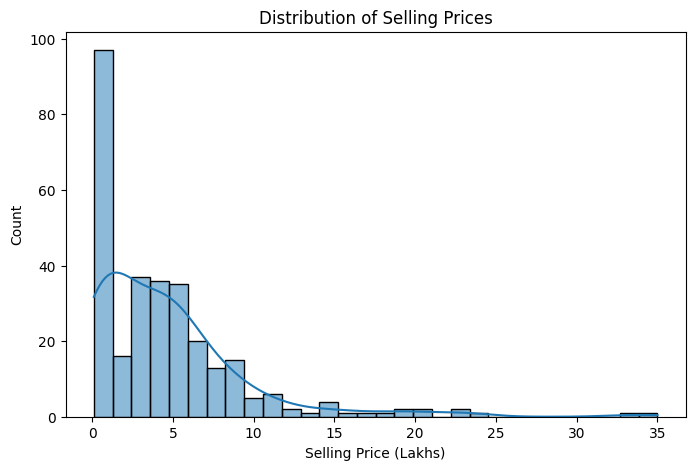

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(df['Selling_Price'], bins=30, kde=True)

plt.title("Distribution of Selling Prices")
plt.xlabel("Selling Price (Lakhs)")
plt.show()

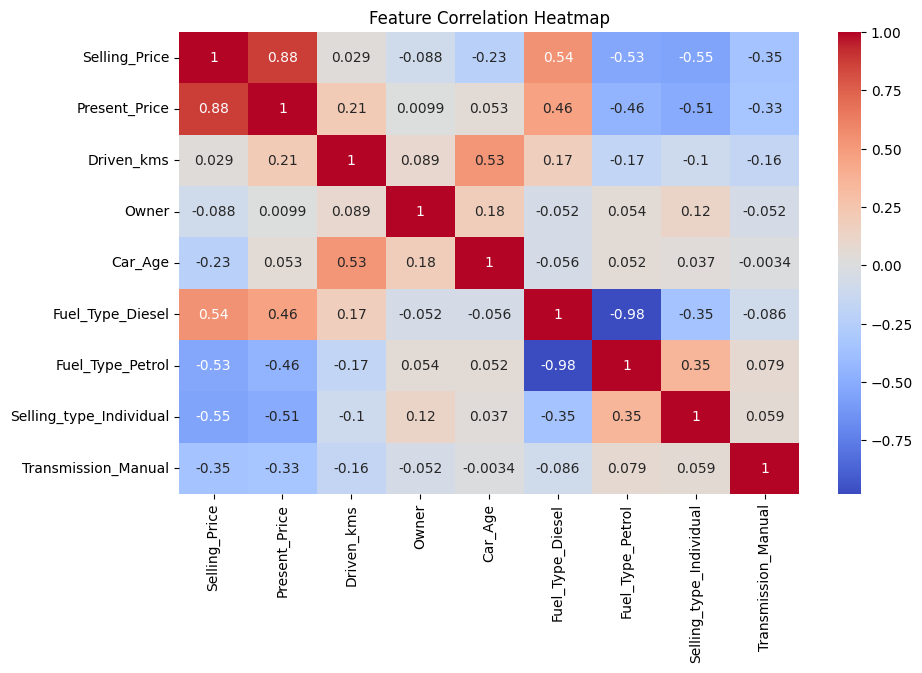

In [10]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title("Feature Correlation Heatmap")
plt.show()

In [11]:
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

print(X.shape)
print(y.shape)

(299, 8)
(299,)


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(239, 8)
(60, 8)


In [19]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

predictions = lr.predict(X_test)

In [20]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, predictions)

mse = mean_squared_error(y_test, predictions)

rmse = mse ** 0.5

r2 = r2_score(y_test, predictions)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 1.4725457508178645
MSE : 6.373125106260712
RMSE: 2.524504923001877
R2 Score: 0.7527233824220484


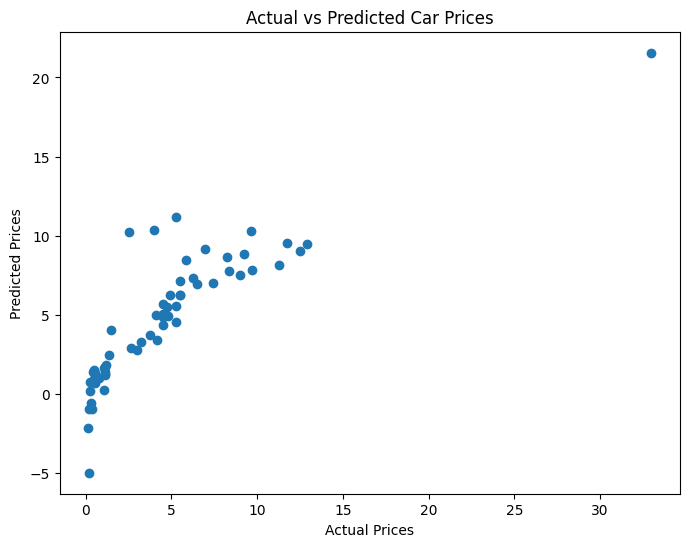

In [21]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted Car Prices")

plt.show()

In [22]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
})

importance = importance.sort_values(
    by='Coefficient',
    ascending=False
)

print(importance)

                   Feature  Coefficient
4         Fuel_Type_Diesel     2.142391
5         Fuel_Type_Petrol     0.692516
2                    Owner     0.640144
0            Present_Price     0.437119
1               Driven_kms    -0.000011
3                  Car_Age    -0.330031
6  Selling_type_Individual    -1.302291
7      Transmission_Manual    -1.573425


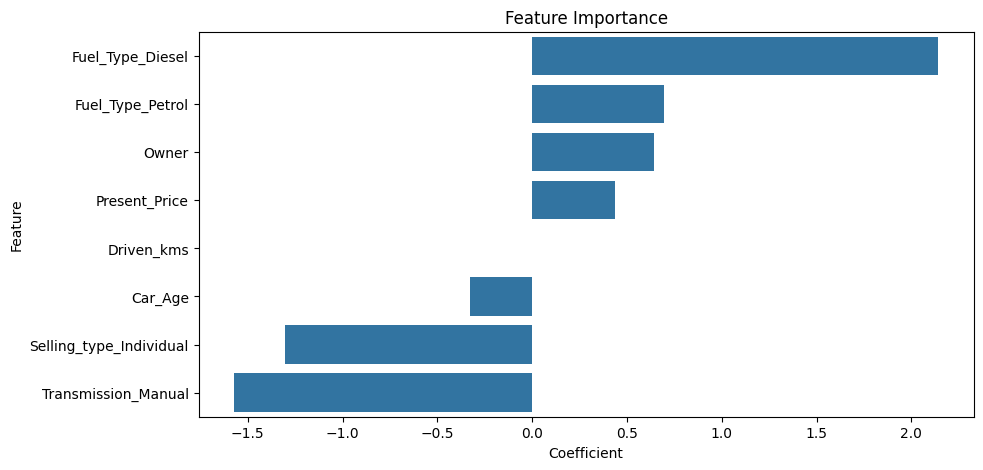

In [23]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=importance,
    x='Coefficient',
    y='Feature'
)

plt.title("Feature Importance")

plt.show()

In [ ]:
# Insights and Conclusions

## Key Findings

'''

* The Linear Regression model got an R² score of 0.75, which means it predicted car prices quite well.
* Present Price was the most important factor in predicting the selling price of a car.
* Older cars usually had lower selling prices.
* Diesel cars generally had higher selling prices than petrol cars.
* Manual cars were usually sold at lower prices than automatic cars.
* Cars sold by individual owners were often cheaper than cars sold by dealers.

'''

## Conclusion

'''

The machine learning model was able to predict car selling prices using features like present price, fuel type, car age, transmission type, and ownership history.

This project shows how machine learning can help buyers, sellers, and car dealers estimate a fair price for a vehicle.

'''

## Real-World Applications

'''

* Online car buying and selling websites
* Car price estimation systems
* Car dealership pricing decisions
* Insurance price assessments
* Used car recommendation platforms

'''
